# Compare P3D with and without HCD Contamination

Attempt to reproduce something similar to the bottom panel of Fig B1 in McQuinn & White (2011, https://arxiv.org/abs/1102.1752)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

In [2]:
from lace.cosmo import cosmology
from cupix.likelihood.theory import Theory

In [3]:
# default cosmology for now
cosmo = cosmology.Cosmology()

In [4]:
# redshift and bias / beta from that paper
z = 2.5
bias = -0.18
beta = 1.0
# close to value used in McQuinn & White, although in there this is kpar smoothing only
kp_Mpc = 0.08 * cosmo.get_dkms_dMpc(z)
print('k_p = {:.3f} 1/Mpc'.format(kp_Mpc))
# HCD model (L_H
b_H = -0.036
beta_H = 0.5
L_H = 7.0  / cosmo.get_h()
print('L_H = {:.3f} Mpc'.format(L_H))
config = dict(bias=bias, beta=beta, q1=0, q2=0, kp_Mpc=kp_Mpc,
              include_hcd=True, b_H=b_H, beta_H=beta_H, L_H=L_H,
              verbose=True)

k_p = 5.782 1/Mpc
L_H = 10.346 Mpc


In [5]:
theory = Theory(z, fid_cosmo=cosmo, config=config)

LyaModel::setup_from_config
LyaModel::get_default_lya_params
initial values {'bias': -0.13827178966115714, 'beta': 1.4178048358716402, 'q1': 0.33369611625260176, 'kvav': 0.5709771352811059, 'av': 0.4055657283063022, 'bv': 1.6647876909430759, 'kp': 12.514370161342079, 'q2': 0.2533086488252884}
final values {'bias': -0.18, 'beta': 1.0, 'q1': 0, 'av': 0.4055657283063022, 'bv': 1.6647876909430759, 'q2': 0, 'kp_Mpc': 5.782362549994954, 'kv_Mpc': 0.25112897347553936}
ContaminantsModel::setup_from_config


In [6]:
def compare_p3d(mu, relative=False):
    k = np.logspace(-3, 1, 1000)
    p3d_lya = theory.get_p3d_lya_Mpc(k=k, mu=mu)
    p3d_lya_hcd = theory.get_p3d_lya_hcd_Mpc(k=k, mu=mu)
    if relative:
        plt.semilogx(k, p3d_lya_hcd / p3d_lya - 1.0)
        plt.ylabel('relative P3D contamination')
        plt.ylim(-0.5, 0.5)
    else:
        plt.loglog(k, p3d_lya, label='Lya only')
        plt.loglog(k, p3d_lya_hcd, label='Lya + HCD')
        p3d_max = np.max(p3d_lya_hcd)
        plt.ylim(0.001*p3d_max, 2*p3d_max)
        plt.ylabel('P3D [Mpc^3]')
        plt.legend()
    plt.xlabel('k [1/Mpc]')
    plt.title(r'$\mu =$ {:.2f}'.format(mu))

recycle transfer function
recycle transfer function


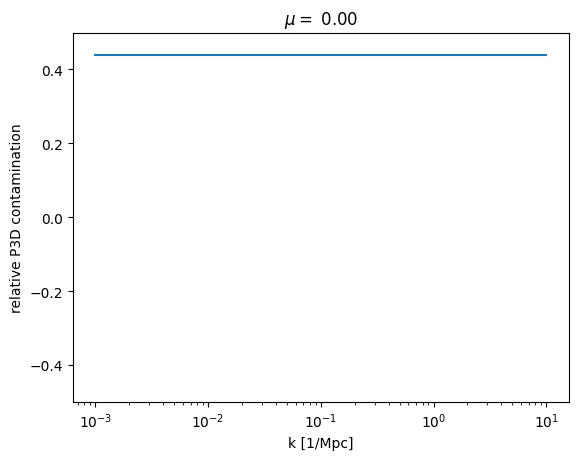

In [7]:
compare_p3d(mu=0.0, relative=True)

recycle transfer function
recycle transfer function


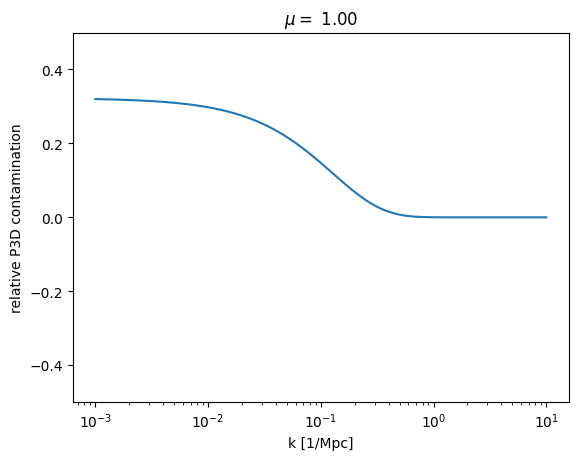

In [8]:
compare_p3d(mu=1.0, relative=True)

## Comparisons with my notebooks:

In [8]:
import h5py
from lace.cosmo import cosmology
import numpy as np
import matplotlib.pyplot as plt
from cupix.likelihood.theory import Theory

In [45]:
with h5py.File('p3d_lya.hdf5', 'r') as f:
    k_los = f['k_los'][:]
    k = f['k'][:]
    plin = f['plin'][:]
    mu = f['mu'][:]
    p3d_lya_me = f['P3d_lya'][:]

In [35]:
cosmo = cosmology.Cosmology()
hubble = 0.71
cosmo.CAMBparams.set_cosmology(H0=hubble*100, ombh2=0.046*(hubble**2), omch2=0.27*(hubble**2))

class: <CAMBparams>
 WantCls = True
 WantTransfer = False
 WantScalars = True
 WantTensors = False
 WantVectors = False
 WantDerivedParameters = True
 Want_cl_2D_array = True
 Want_CMB = True
 Want_CMB_lensing = True
 DoLensing = True
 NonLinear = NonLinear_none
 Transfer: <TransferParams>
   high_precision = False
   accurate_massive_neutrinos = False
   kmax = 0.9
   k_per_logint = 0
   PK_num_redshifts = 1
   PK_redshifts = [0.0]
 want_zstar = False
 want_zdrag = False
 min_l = 2
 max_l = 2500
 max_l_tensor = 600
 max_eta_k = 5000.0
 max_eta_k_tensor = 1200.0
 ombh2 = 0.0231886
 omch2 = 0.136107
 omk = 0.0
 omnuh2 = 0.000644866570625114
 H0 = 71.0
 TCMB = 2.7255
 YHe = 0.24619933960101897
 num_nu_massless = 2.0293333333333337
 num_nu_massive = 1
 nu_mass_eigenstates = 1
 share_delta_neff = False
 nu_mass_degeneracies = [1.0146666666666666]
 nu_mass_fractions = [1.0]
 nu_mass_numbers = [1]
 InitPower: <InitialPowerLaw>
   tensor_parameterization = tensor_param_rpivot
   ns = 0.9665
 

In [37]:
# redshift and bias / beta from that paper
z = 2.5
bias = -0.18
beta = 1.0
# close to value used in McQuinn & White, although in there this is kpar smoothing only
kp_Mpc = 0.08 * cosmo.get_dkms_dMpc(z)
print('k_p = {:.3f} 1/Mpc'.format(kp_Mpc))
# HCD model (L_H
b_H = -0.036
beta_H = 0.5
L_H = 7.0  / cosmo.get_h()
print('L_H = {:.3f} Mpc'.format(L_H))
config = dict(bias=bias, beta=beta, q1=0, q2=0, kp_Mpc=kp_Mpc,
              include_hcd=True, b_H=b_H, beta_H=beta_H, L_H=L_H,
              verbose=True)

k_p = 6.136 1/Mpc
L_H = 9.859 Mpc


In [38]:
theory = Theory(z, fid_cosmo=cosmo, config=config)

LyaModel::setup_from_config
LyaModel::get_default_lya_params
initial values {'bias': -0.13827178966115714, 'beta': 1.4178048358716402, 'q1': 0.33369611625260176, 'kvav': 0.5709771352811059, 'av': 0.4055657283063022, 'bv': 1.6647876909430759, 'kp': 12.514370161342079, 'q2': 0.2533086488252884}
final values {'bias': -0.18, 'beta': 1.0, 'q1': 0, 'av': 0.4055657283063022, 'bv': 1.6647876909430759, 'q2': 0, 'kp_Mpc': 6.136199149752336, 'kv_Mpc': 0.25112897347553936}
ContaminantsModel::setup_from_config


In [41]:
p3d_lya_cupix = []
for mu_value in mu:
    p3d_lya_cupix.append(theory.get_p3d_lya_Mpc(k=k, mu=mu_value))
p3d_lya_cupix = np.array(p3d_lya_cupix)

recycle transfer function
recycle transfer function
recycle transfer function
recycle transfer function
recycle transfer function
recycle transfer function
recycle transfer function
recycle transfer function
recycle transfer function
recycle transfer function
recycle transfer function


In [46]:
p3d_lya_cupix.shape, p3d_lya_me.shape

((11, 4098), (11, 4098))

In [47]:
ratio = p3d_lya_cupix/p3d_lya_me

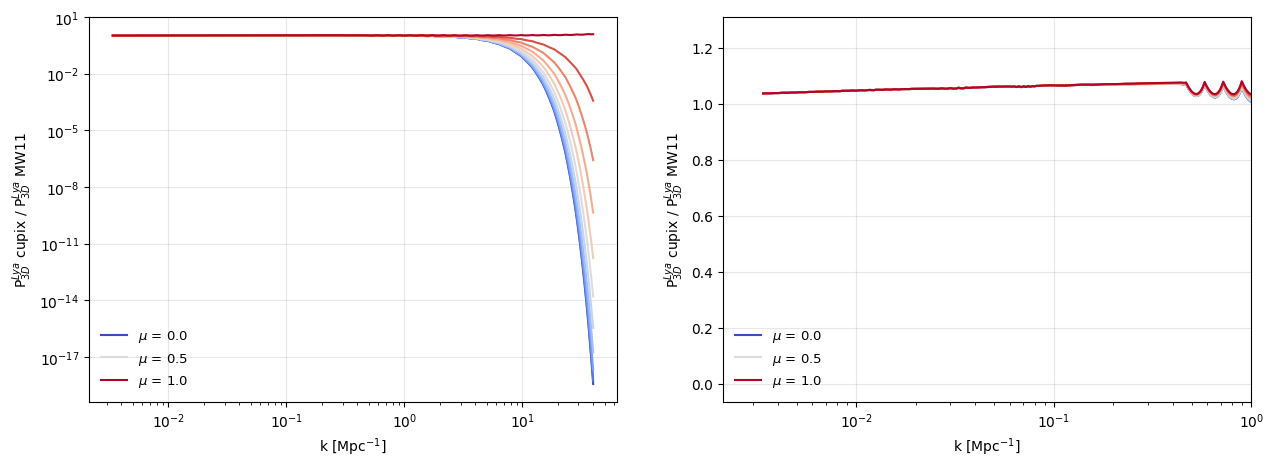

In [57]:
plt.figure(figsize=(15, 5))


plt.subplot(1, 2, 1)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)
for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, ratio[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, ratio[i, :])
plt.xscale('log')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$ cupix / P$_{3D}^{Lya}$ MW11')

plt.subplot(1, 2, 2)
colors = plt.cm.coolwarm(np.linspace(0,1,len(mu)))     
plt.gca().set_prop_cycle('color', colors)
for i in np.arange(len(mu)):
    if i in [0, 5, 10]:
        plt.plot(k, ratio[i, :], label = '$\mu$ = %.1f' %mu[i])
    else:
        plt.plot(k, ratio[i, :])
plt.xscale('log')
plt.xlim(right=1e0)
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'k [Mpc$^{-1}$]')
plt.ylabel(r'P$_{3D}^{Lya}$ cupix / P$_{3D}^{Lya}$ MW11');

De modo que hay algo raro...